In [ ]:
%pip install langchain langchain_community langgraph
%pip install pypdf
%pip install langchain-google-genai
%pip install langchain-nvidia-ai-endpoints 
%pip install faiss-cpu

In [16]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langgraph.graph import START, StateGraph, END
from langchain_nvidia_ai_endpoints import NVIDIAEmbeddings
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from dotenv import load_dotenv
load_dotenv()
import os
from typing import TypedDict, List
from pydantic import BaseModel
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_tavily.tavily_search import TavilySearch
import re

In [ ]:
docs = (PyPDFLoader('./docs/Transformers_and_llm.pdf').load()  + PyPDFLoader('./docs/Hands_On_llm.pdf').load() + PyPDFLoader('./docs/Introduction_to_Machine_Learning_with_Python.pdf').load())
docs

In [ ]:
len(docs)

In [4]:
chunks = RecursiveCharacterTextSplitter(chunk_size = 800, chunk_overlap=100).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode('utf-8', 'ignore').decode('utf-8', 'ignore')

In [5]:
embeddings = NVIDIAEmbeddings(
  model="nvidia/nv-embed-v1", 
  api_key=os.getenv('NVIDIA_EMBEDDINGS_API_KEY'), 
  truncate="NONE", 
  )
vector_store = FAISS.from_documents(chunks, embeddings)

In [6]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [7]:
llm = ChatNVIDIA(
  model="moonshotai/kimi-k2-thinking",
  api_key=os.getenv('NVIDIA_CHAT_API_KEY'), 
  temperature=1,
  top_p=0.9,
  max_tokens=16384,
)

C:\Users\OMM\AppData\Local\Temp\ipykernel_45300\1118434693.py:1: DeprecationWarning: The 'max_tokens' parameter is deprecated and will be removed in a future version. Please use 'max_completion_tokens' instead.
  llm = ChatNVIDIA(


In [8]:
upper_thresh = 0.7
lower_thresh = 0.3

In [11]:
class State(TypedDict):
    question: str
    context: List[Document]

    good_docs: List[Document]
    verdict: str

    web_query: str
    web_docs: List[Document]

    refined_context: List[Document]
    result: str

In [23]:
class EvaluatorScore(BaseModel):
    score: float
    reason: str

eval_prompt = ChatPromptTemplate(
    [
        (
            'system',
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain = eval_prompt | llm.with_structured_output(EvaluatorScore)

def retrieval_evaluator(state: State):
    q = state['question']
    scores: List[float] = []
    reasons: List[str] = []
    good: List[Document] = []

    for d in state["context"]:
        out = doc_eval_chain.invoke({'question': q, 'chunk': d.page_content})
        scores.append(out.score)
        reasons.append(out.reason)

        if out.score > lower_thresh:
            good.append(d)
    
    if any(s>upper_thresh for s in scores):
        return {
            "good_docs": good,
            "verdict": 'relevant'
        }
    if all(s<lower_thresh for s in scores):
        return {
            'good_docs': [],
            'verdict': 'irrelevant'
        }
    # ambiguous
    return {
        'good_docs': good,
        'verdict': 'ambiguous'
    }



In [12]:
class WebQuery(BaseModel):
    query: str

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)

def query_rewrite(state: State):
    out = rewrite_chain.invoke({'question': state['question']})
    return {"web_query": out.query}

In [14]:
tavily = TavilySearch(max_results=5)

def web_search(state: State):
    results = tavily.invoke({'query': state['web_query']})

    web_docs: List[Document] = []
    for r in results['results']:
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"
        web_docs.append(Document(page_content=text, metadata={"url": url, "title": title}))
    
    return {'web_docs': web_docs}

In [ ]:
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

class KeepOrDrop(BaseModel):
    keep: bool


filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)

def refine(state: State) -> State:
    q = state["question"]

    if state['verdict'] == 'relevant':
        docs_to_use = state['good_docs']
    elif state['verdict'] == 'irrelevant':
        docs_to_use = state['web_docs']
    else:
        docs_to_use = state["good_docs"] + state["web_docs"]
    
    context = "\n\n".join(d.page_content for d in docs_to_use).strip()

    strips = decompose_to_sentences(context)

    kept: List[str] = []
    for s in strips:
        if filter_chain.invoke({'question': state['question'], 'sentence': s}).keep:
            kept.append(s)
        
    refined_context = "\n".join(kept).strip()

    return {
        'reinfed_context': refined_context
    }

In [18]:
def retrieve(state: State):
    q=state['question']
    return {'context': retriever.invoke(q)}

In [ ]:
prompt = ChatPromptTemplate(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)

def generator(state: State):
    out = (prompt | llm).invoke({'question': state['question'], 'context': state['refined_context']})
    return {'result': out.content}

In [17]:
def route_after_eval(state: State) -> str:
    if state["verdict"] == "relevant":
        return "refine"
    else:
        return "rewrite_query"

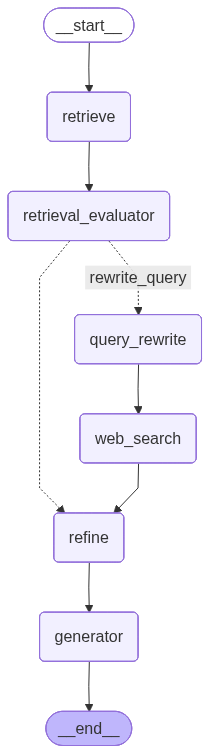

In [25]:
g = StateGraph(State)
g.add_node('retrieve', retrieve)
g.add_node('retrieval_evaluator', retrieval_evaluator)
g.add_node('query_rewrite', query_rewrite)
g.add_node('web_search', web_search)
g.add_node('refine', refine)
g.add_node('generator', generator)

g.add_edge(START, 'retrieve')
g.add_edge('retrieve', 'retrieval_evaluator')
g.add_conditional_edges('retrieval_evaluator', route_after_eval, {
    'refine': 'refine',
    "rewrite_query": 'query_rewrite',
})
g.add_edge('query_rewrite', 'web_search')
g.add_edge("web_search", "refine")
g.add_edge("refine", 'generator')
g.add_edge('generator', END)

workflow= g.compile()
workflow

In [26]:
resp = workflow.invoke({'question': 'What is transformer?', 'context': [], 'answer': ''})
print(resp)

{'question': 'What is transformer?', 'context': [Document(id='7d897f96-f8ba-413b-9177-7be3108b851e', metadata={'producer': 'pdfTeX-1.40.21', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-02-03T15:00:33-08:00', 'author': '', 'title': '', 'subject': '', 'keywords': '', 'moddate': '2024-02-03T15:00:33-08:00', 'trapped': '/False', 'ptex.fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) kpathsea version 6.3.2', 'source': './docs/Transformers_and_llm.pdf', 'total_pages': 30, 'page': 2, 'page_label': '3'}, page_content='10.1 • T HE TRANSFORMER : A S ELF -ATTENTION NETWORK 3\ntransformers are a neural architecture that can handle distant information. But unlike\nLSTMs, transformers are not based on recurrent connections (which can be hard to\nparallelize), which means that transformers can be more efﬁcient to implement at\nscale.\nTransformers are made up of stacks of transformer blocks, each of which is a\nmultilayer network that maps sequences of input ve

In [27]:
print(resp['result'])

 Based on the context provided, a transformer is:

A neural architecture that can handle distant information without using recurrent connections (making it non-recurrent), which makes it more efficient to implement at scale compared to LSTMs. Transformers are built from stacks of transformer blocks, where each block is a multilayer network that maps sequences of input vectors to sequences of output vectors of the same length.

Key components and characteristics:
- **Core innovation**: Self-attention layers, which use attention heads to model how surrounding words are relevant for processing the current word. Self-attention maps input sequences to output sequences of the same length.
- **Transformer block structure**: Each block consists of a single attention layer followed by a feedforward layer, with residual connections and layer normalizations after each.
- **Stacking**: Transformer blocks can be stacked to create deeper and more powerful networks.
- **For language modeling**: When 